# Detección de Spam a través de modelos de Machine Learning

## 1.Introducción

En esta práctica que veremos a continuación, trataremos de realizar todos los pasos que se han de aplicar a la hora de afrontar un problema de clasificación y predicción con modelos de Machine Learning.

En este caso en concreto vamos a tratar de solventar un problema común en la ciberseguridad como es el Spam.
Como muchos de vosotros ya sabréis, el spam es considerado una forma de intrusión no deseada a través de canales de comunicación online, como puede ser el correo electrónico, sms, redes sociales, etc.

Para ello vamos a implementar varios modelos de Machine Learning que a partir de una serie de datos y el aprendizaje de los mismos, logrará clasificar los mensajes que recibamos en Spam o no y predecir unos posibles casos.

Esta práctica se deberá realizar en el lenguaje de programación Phyton y constará de cinco apartados ordenados, algunos más guiados y algunos que requerirán de trabajo autónomo para realizarlo.

El entorno de desarrollo será Google Colab, un servicio de Google en el cuál podremos ejecutar nuestro código de forma interpretada e independiente (por celdas).


<br><br><br><br>


**1.** Instalación de entornos, dependencias y base de datos.

**2.** Procesamiento de los datos, familiarización con la base de datos.

**3.** Preparación del dataset para entrenarlo.

**4.** Selección de modelos y entrenamiento.

**5.** Comparativa y evaluación de los modelos.

<br>

Dicho todo esto, mucha suerte con la realización de la misma y... !bienvenido al fascinante mundo del Machine Learning!






## 1. Instalación de entornos, dependencias y base de datos.

Primero de todos vamos a descargar la base de datos para poder utilizar los datos que nos proporciona. En este caso usaremos una base de datos de uso público que descargaremos de forma local y exportaremos a Google Colab.

Como habrá visto, Google Colab es un entorno en que puedes subir a archivos y acceder a ellos como si estubieran en local, poniendo directamente la ruta en el que se encuentras dentro del entorno.

*Tip: para saber la ruta de un fichero subido en colab basta con seleccionar los tres puntos del fichero y en opciones seleccionar copiar ruta del fichero.*

La base de datos la puedes descargar del siguiente link que enlaza con un github:

https://github.com/NStugard/Intro-to-Machine-Learning/blob/main/spam.csv

Una vez descargada súbela a google colab antes de seguir.

A continuación veamos con que entornos y librerías vamos a trabajar:

**NumPy:**  Proporciona estructuras de datos eficientes, como los arrays multidimensionales (ndarrays), junto con una amplia variedad de funciones matemáticas y operaciones de álgebra lineal.  
Utilizaremos NumPy para manipular los datos en forma de matrices numéricas. Por ejemplo, cuando preprocesemos los datos de texto y los convirtamos en características numéricas para alimentar nuestros modelos de Machine Learning.

**Pandas:** Utilizaremos Pandas para cargar, limpiar y explorar los datos de texto que utilizaremos en nuestra tarea de detección de spam. El DataFrame de Pandas nos permitirá cargar fácilmente los datos de un archivo CSV (dataset) y realizar operaciones de limpieza y preprocesamiento de los mismos.

**Scikit-learn (también conocido como sklearn):** es una biblioteca de aprendizaje automático de código abierto y una de las herramientas más utilizadas y populares para el aprendizaje automático en Python. Proporciona una amplia variedad de algoritmos de aprendizaje supervisado y no supervisado.






In [24]:
#Importamos todas las librerías necesarias para realizar la práctica

import pandas as pd #cargar y gestionar dataset
import numpy as np #calculos con el dataset
import matplotlib.pyplot as plt #gráficos

#StopWords
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

#modelos de Mahine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer #transformar en valor numérico
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns

#redes neuronales
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Embedding


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Eze\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Eze\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Eze\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


## 2. Procesamiento de los datos, familiarización con la base de datos

Una vez tenemos instaladas todas las dependencias necesarias ya podemos empezar a trabajar con la base de datos.

La base de datos con la que vamos a trabajar consta de dos columnas, "Category" y "Message". Hemos de tener en cuenta que esta base de datos es inglesa y por tanto todos los mensajes que contiene estan en ese idioma.

La mejor forma de conocer una base de datos con la que vamos a trabajar es familiarizarse con ella trasteando un poco y viendo que atributos y tipos de datos tiene.

A continuación busca información sobre como cargar y visualizar una base de datos en pandas para que puedas observar de mejor forma como estan organizados los datos.

In [ ]:
#Prueba a cargar y visualizar los datos, puedes obtener gráficos sobre el mismo dataset para entender mejor como se distribuyen los mismos.
#Cargar dataset
spam_df = pd.read_csv('../ipynbs/spam.csv')
#Visualizar dataset
spam_df

In [14]:
#Descripción del dataset y su información
spam_df.describe()
spam_df['Category'].describe()

count     5572
unique       2
top        ham
freq      4825
Name: Category, dtype: object

In [15]:
#Agrupar por categorías y ver resultado
spam_df.groupby('Category').describe()

Message                                                            \
           count unique                                                top   
Category                                                                     
ham         4825   4516                             Sorry, I'll call later   
spam         747    641  Please call our customer service representativ...   

               
         freq  
Category       
ham        30  
spam        4

## 3. Preparación del dataset para entrenarlo

Una vez hemos trasteado con la base de datos a nivel básico y tenemos una idea de que contiene podemos empezar a trabajar con ella.
Este proceso es muy importante para que el resultado final del modelo sea preciso ya que son los datos de los que se alimentará para aprender y poder clasificar correctamente los mensajes.

Llegado a este punto, ¿que se te ocurre que sería relevante comprobar para que los datos no contengan ruido que molesta a nuestro modelo?

En este apartado igual que en el anterior te orientaré con las comprovaciones que siempre se han de hacer si o si, pero te animo a que pienses y pruebes las dudas que te surjan aparte de lso que planteamos aquí.

Alerta Spoiler: espero que hayas pensado por ti mismo algunas opciones, procedemos a explicar las que llevaremos a cabo.

En el caso de los datasets lo primero es garantizar que los valores que le pasemos a nuestros modelos sean de tipo numérico (mas adelante lo tendremos en cuenta). Un caso que hemos de mirar es que el dataset no tenga filas o columnas nulas, y en caso de tenerlas eliminarlas porque serían ruido y molestarían a nuestro modelo.

Además podemos comprobar ciertas cosas del dataset, como si contiene muchas filas repetidas, las palabras más comunes en un mensaje de spam o no spam, el tamaño de los mensajes según su categoría, valores válidos para cada columna,etc.

In [16]:
#Vamos a descubrir que esconde nuestra base de datos, posibles problemas y soluciones
#Comprobamos que no hayan valores nulos dentro del dataset
valores_nulos = spam_df.isnull().values.any()
print(valores_nulos)
#Comprobamos que los valores del dataset son válidos (ej: categoría solo puede ser "spam" o "ham")
valores_validos = spam_df['Category'].isin(['spam', 'ham']).all()

if valores_validos:
    print("Todos los valores de la columna 'Category' son 'spam' o 'ham'.")
else:
    print("¡Hay valores en la columna 'Category' que no son 'spam' o 'ham'!")

False
Todos los valores de la columna 'Category' son 'spam' o 'ham'.


In [17]:
#En caso de que hayan valores nulos, como los eliminaríamos?
spam_df = spam_df.dropna()
#Comprobamos si hay filas duplicadas (¿hace falta?)
filas_repetidas = spam_df[spam_df.duplicated()]

if not filas_repetidas.empty:
    print("Filas duplicadas encontradas:")
    print(filas_repetidas)
else:
    print("No se encontraron filas duplicadas en el DataFrame.")

Filas duplicadas encontradas:
     Category                                            Message
103       ham  As per your request 'Melle Melle (Oru Minnamin...
154       ham  As per your request 'Melle Melle (Oru Minnamin...
207       ham  As I entered my cabin my PA said, '' Happy B'd...
223       ham                             Sorry, I'll call later
326       ham                   No calls..messages..missed calls
...       ...                                                ...
5524     spam  You are awarded a SiPix Digital Camera! call 0...
5535      ham  I know you are thinkin malaria. But relax, chi...
5539      ham                         Just sleeping..and surfing
5553      ham                        Hahaha..use your brain dear
5558      ham                             Sorry, I'll call later

[415 rows x 2 columns]


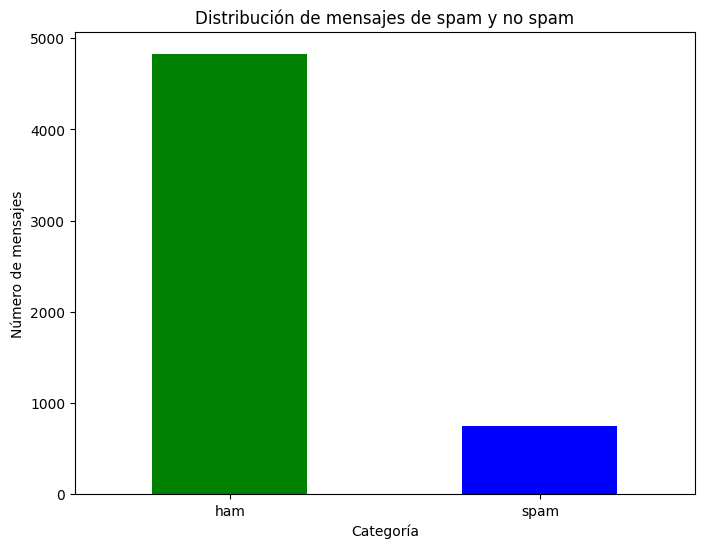

In [19]:
# Contar el número de mensajes en cada categoría + grafico de barras
counts = spam_df['Category'].value_counts()
plt.figure(figsize=(8, 6))
counts.plot(kind='bar', color=['green', 'blue'])
plt.title('Distribución de mensajes de spam y no spam')
plt.xlabel('Categoría')
plt.ylabel('Número de mensajes')
plt.xticks(rotation=0)  # Para evitar que los nombres de las categorías se superpongan en el eje x
plt.show()

<Figure size 1000x600 with 0 Axes>

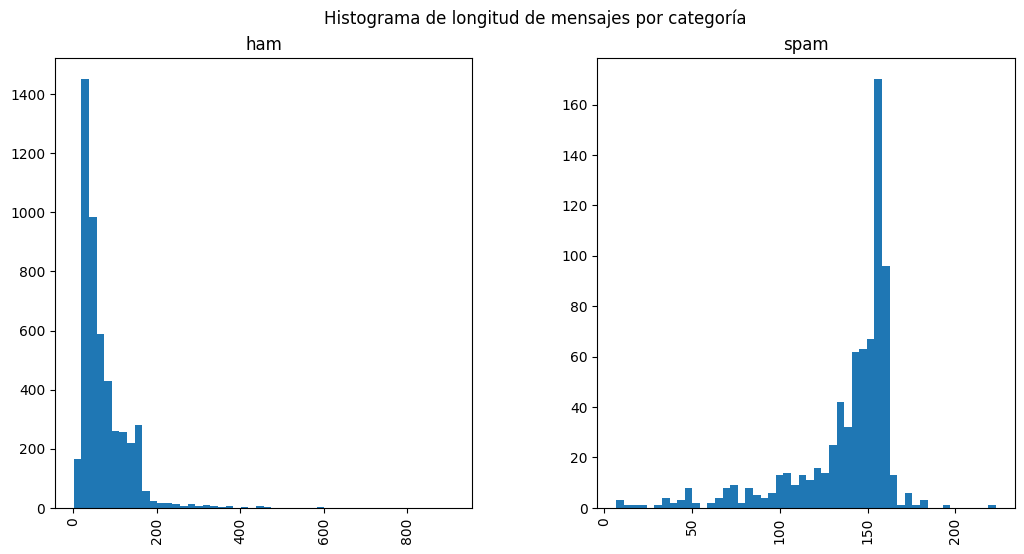

In [20]:
#Longitud de mensajes según categoría (podemos hacer histograma)
plt.figure(figsize=(10, 6))
spam_df['message_length'] = spam_df['Message'].apply(len)
spam_df.hist(column='message_length', by='Category', bins=50, figsize=(12, 6))
plt.suptitle('Histograma de longitud de mensajes por categoría')
plt.show()

In [21]:
#Conteo de palabras mas comunes en spam y ham, que ocurre?
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(spam_df['Message'])
word_freq = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

spam_words_freq = word_freq[spam_df['Category'] == 'spam'].sum().sort_values(ascending=False)
print("Palabras más comunes en mensajes de spam:")
print(spam_words_freq.head(10))

Palabras más comunes en mensajes de spam:
to      688
call    352
you     297
your    264
free    224
for     204
the     203
now     199
or      188
txt     163
dtype: int64


In [22]:
ham_words_freq = word_freq[spam_df['Category'] == 'ham'].sum().sort_values(ascending=False)
print("\nPalabras más comunes en mensajes no spam:")
print(ham_words_freq.head(10))


Palabras más comunes en mensajes no spam:
you     1948
to      1562
the     1133
and      858
in       823
me       777
my       754
is       739
it       718
that     560
dtype: int64


Ya habrás visto llegado a este punto que las palabras más comunes en ambas categorías coinciden, y es que existen en todos los lenguajes muchas palabras que se usan muy por encima de la media.

Por ese motivose crearon lo llamado stopwords, una lista de palabras que contiene esas palabras y que en nuestro caso nos será útil de eliminar de nuestro mensajes porque generarán más ruido que información útil.

Curiosidad:
En este repositorio puedes ver un ejemplo de stopwords en varios idiomas incluyendo español y catalán: https://github.com/Alir3z4/stop-words/tree/master



In [25]:
#Eliminamos las stopwords de nuestros mensajes. TIP: mirar las dependencias para ver las librerías que usaremos.

# Define una función para eliminar las stopwords de un texto
def eliminar_stopwords(texto):
    # Tokeniza el texto en palabras
    palabras = word_tokenize(texto)

    # Filtra las palabras para eliminar aquellas que están en la lista de stopwords
    palabras_filtradas = [palabra for palabra in palabras if palabra.lower() not in stopwords.words('english')]

    # Une las palabras nuevamente en un solo texto
    texto_limpio = ' '.join(palabras_filtradas)

    return texto_limpio

# Aplica la función eliminar_stopwords a la columna 'texto' del DataFrame
spam_df['Message'] = spam_df['Message'].apply(eliminar_stopwords)

#Podemos comprobar una ve eliminadas la diferencia entre antes y ahora.
spam_df

,Category,Message,message_length
0,ham,"Go jurong point , crazy .. Available bugis n g...",111
1,ham,Ok lar ... Joking wif u oni ...,29
2,spam,Free entry 2 wkly comp win FA Cup final tkts 2...,155
3,ham,U dun say early hor ... U c already say ...,49
4,ham,"Nah n't think goes usf , lives around though",61
...,...,...,...
5567,spam,2nd time tried 2 contact u. U £750 Pound prize...,160
5568,ham,ü b going esplanade fr home ?,36
5569,ham,"Pity , * mood . ... suggestions ?",57
5570,ham,guy bitching acted like 'd interested buying s...,125


Antes de pasar a entrenar el modelo (ánimos, ya queda poco para llegar al final) queda una parte muy importante, y es que como mencionamos antes, nuestros modelos de Machine Learning no van a poder entender datos que no sean numéricos, por tanto queda transformar nuestro dataset en datos numéricos.

En nuestro caso tenemos 2 columnas, "Category" y "Messages".
Por parte de category os recomiendo que simplemente creeis una nueva columna en el dataset con 1 o 0, según si es spam (1) o si no lo es (0).

Para la otra columna, hemos de encontrar algo que le sea útil a nuestro programa para clasificar el mensaje en spam o no.

Para ello usaremos CountVectorizer (visualizar las dependencias del principio). Esta herramienta nos servirá para transformar nuestros mensajes de texto en matrices que mostrarán la cantidad de veces que esta cada palabra a en el total y expresará el numero.

Con esto le pasaremos "vectores" de numeros con la cantidad de veces que se usa cada numero, a continuación te pongo un ejemplo que te ayudará a verlo con más claridad.


###Ejemplo

<div style="background-color: #f0f0f0; border: 1px solid #ccc; padding: 10px;">


   - Conjunto de entrenamiento:

          ['hola mundo', 'hola a todos', 'bienvenidos al mundo']


   - Vocabulario construido:
     ```
     ['hola', 'mundo', 'todos', 'bienvenidos']
     ```
  
- Test:

      ['hola amigos','bienvenidos al universo']

- Después de aplicar este paso
     ```
     [[1, 0, 0, 0],
      [0, 0, 0, 1]]
     ```
    

   - Explicación de los resultados:
     - En el primer documento de prueba "hola amigos", la palabra "hola" está presente en el vocabulario, pero "amigos" no lo está. Entonces, obtenemos [1, 0, 0, 0].
     - En el segundo documento de prueba "bienvenidos al universo", las palabras "bienvenidos" y "universo" están presentes en el vocabulario, pero "al" no lo está. Entonces, obtenemos [0, 0, 0, 1].

</div>

Por último en este apartado solo queda splitear el dataset en conjunto de entrenamiento y test, para ello solo es necesario llamar a una función correctamente de las que hemos importado en las dependencias.

Busca información sobre cual puede ser y como llamarla.

Una vez hecho el split, convierte el x_test y el x_train en arrays con la función toarray()





In [ ]:
#Creación nueva columna llamada Spam con 1 o 0 según la categoría
spam_df['spam'] = spam_df['Category'].apply(lambda x:1 if x == 'spam' else 0)

#Spliteamos el dataset en train, test (mirar parámetro test_size)
x_train, x_test, y_train, y_test = train_test_split(spam_df.Message, spam_df.spam, test_size = 0.25)
#Miramos que tengo en conjunto x/y de entrenamiento
x_train.describe()
y_train.describe()
#Transformación de los mensajes a valor numérico
cv = CountVectorizer()
x_train_transformed = cv.fit_transform(x_train)
x_test_transformed = cv.transform(x_test)

#Función toarray()
x_train_transformed.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4179, 7364))

: 

##4. Selección de modelos y entrenamiento.

Felicidades guerrer@, has superado la parte más tediosa de la práctica y has demostrado de lo que eres capaz, ahora queda la parte más "divertida" de ella, vamos a probar los modelos de Machine Learning y ver si conseguimos detectar ese irritante spam que tanto odiamos.

Vamos a intentar entrenar varios modelos y analizar que porcentaje de accuracy (acierto) nos dan.

Empezemos por el primero, el modelo de Naive-Bayes.

####  **4.1 Naive-Bayes**

Busca información sobre como entrenar un modelo de Naive-Bayes con sklearn y implementalo.

Además ya puedes probar textos tuyos para comprobar si el modelo acierta en la detección y por último puedes intentar saber que accuracy tiene el modelo.


In [ ]:
#Entrena el modelo Naive-Bayes
model = MultinomialNB()
model.fit(x_train_transformed, y_train)
#Pruebas de detección propias (recuerda pasar el texto por el transform)
email_bien = ["hi peter, how are you today?"]
email_ham_count = cv.transform(email_bien)
print(model.predict(email_ham_count))

email1 = ["iphone 5 congratulations"]
e1 = cv.transform(email1)
print(model.predict(e1))

email2 = ["congratulations you win money"]
e2 = cv.transform(email2)
print(model.predict(e2))

email3 = ["do you want to visit me on thursday?"]
e3 = cv.transform(email3)
print(model.predict(e3))
#Evalua el modelo obteniendo algunas métricas (almenos el accuracy para saber si acierta)
x_test_count = cv.transform(x_test)
acc = model.score(x_test_count, y_test)
print("Accuracy:", acc)

[0]
[1]
[1]
[0]
Accuracy: 0.9856424982053122


####  **4.2 KNN**
Realiza lo mismo del punto 4.1 pero con el knn, busca información sobre este modelo y trata de optimizarlo si es posible.

In [ ]:
#Entrena el modelo KNN
valores_k = [1, 3, 5, 7, 9]
for k in valores_k:
    # Inicializa el clasificador KNN con el valor de k específico
    knn = KNeighborsClassifier(n_neighbors=k)

    # Entrena el modelo KNN
    knn.fit(x_train_transformed, y_train)

    # Realiza predicciones en el conjunto de prueba
    predictions = knn.predict(x_test_transformed.toarray())

    # Calcula la precisión del modelo
    accuracy = accuracy_score(y_test, predictions)

    # Imprime la precisión del modelo para el valor de k actual
    print(f"KNN con k={k}: Accuracy = {accuracy:.2f}")

#Pruebas de detección propias (recuerda pasar el texto por el transform)
email_bien = ["hi peter, how are you today?"]
email_ham_count = cv.transform(email_bien)
print(model.predict(email_ham_count))

email1 = ["iphone 5 congratulations"]
e1 = cv.transform(email1)
print(model.predict(e1))

email2 = ["congratulations you win money"]
e2 = cv.transform(email2)
print(model.predict(e2))

email3 = ["do you want to visit me on thursday?"]
e3 = cv.transform(email3)
print(model.predict(e3))

#Evalua el modelo obteniendo algunas métricas (almenos el accuracy para saber si acierta)


KNN con k=1: Accuracy = 0.95
KNN con k=3: Accuracy = 0.94
KNN con k=5: Accuracy = 0.92
KNN con k=7: Accuracy = 0.91
KNN con k=9: Accuracy = 0.90
[0]
[1]
[1]
[0]


####  **4.3 Decision Tree**
Realiza lo mismo del punto 4.1 pero con el decision tree, busca información sobre este modelo y trata de implementarlo.

In [ ]:
#Entrena el modelo decision tree
profundidades_maximas = [None, 10, 20, 30, 40]

for profundidad_maxima in profundidades_maximas:
    decision_tree = DecisionTreeClassifier(max_depth=profundidad_maxima)
    decision_tree.fit(x_train_transformed, y_train)

    predictions = decision_tree.predict(x_test_transformed.toarray())
    accuracy = accuracy_score(y_test, predictions)
    print(f"Decision Tree con profundidad máxima {profundidad_maxima}: Accuracy = {accuracy:.2f}")

#Pruebas de detección propias (recuerda pasar el texto por el transform)
email_bien = ["hi peter, how are you today?"]
email_ham_count = cv.transform(email_bien)
print(model.predict(email_ham_count))

email1 = ["iphone 5 congratulations"]
e1 = cv.transform(email1)
print(model.predict(e1))

email2 = ["congratulations you win money"]
e2 = cv.transform(email2)
print(model.predict(e2))

email3 = ["do you want to visit me on thursday?"]
e3 = cv.transform(email3)
print(model.predict(e3))
#Evalua el modelo obteniendo algunas métricas (almenos el accuracy para saber si acierta)


Decision Tree con profundidad máxima None: Accuracy = 0.97
Decision Tree con profundidad máxima 10: Accuracy = 0.96
Decision Tree con profundidad máxima 20: Accuracy = 0.97
Decision Tree con profundidad máxima 30: Accuracy = 0.97
Decision Tree con profundidad máxima 40: Accuracy = 0.97
[0]
[1]
[1]
[0]


####  **4.4 Regresión logística**
Realiza lo mismo del punto 4.1 pero con un modelo de regresión logística, busca información sobre este modelo y trata de implementarlo.

In [ ]:
#Entrena el modelo de regresión logística
logistic_regression = LogisticRegression(max_iter=1000)

# Entrena el modelo de Regresión Logística
logistic_regression.fit(x_train_transformed, y_train)

# Realiza predicciones en el conjunto de prueba
predictions = logistic_regression.predict(x_test_transformed.toarray())

# Calcula la precisión del modelo
accuracy = accuracy_score(y_test, predictions)

# Imprime la precisión del modelo
print(f"Regresión Logística: Accuracy = {accuracy:.2f}")
#Pruebas de detección propias (recuerda pasar el texto por el transform)
email_bien = ["hi peter, how are you today?"]
email_ham_count = cv.transform(email_bien)
print(model.predict(email_ham_count))

email1 = ["iphone 5 congratulations"]
e1 = cv.transform(email1)
print(model.predict(e1))

email2 = ["congratulations you win money"]
#añadir stopword
e2 = cv.transform(email2)
print(model.predict(e2))

email3 = ["do you want to visit me on thursday?"]
e3 = cv.transform(email3)
print(model.predict(e3))


Regresión Logística: Accuracy = 0.98
[0]
[1]
[1]
[0]


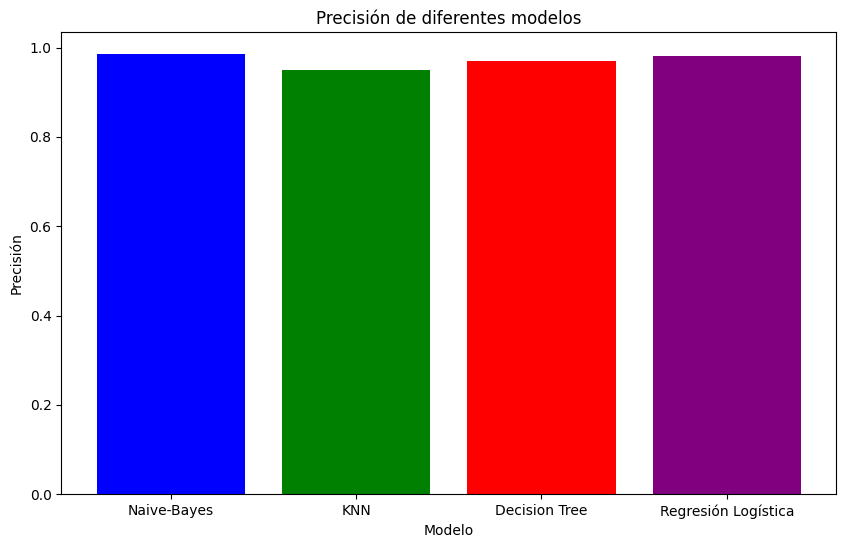

In [ ]:
# Definir los nombres de los modelos y sus respectivas precisión
modelos = ['Naive-Bayes', 'KNN', 'Decision Tree', 'Regresión Logística']
precision = [0.985, 0.95, 0.97, 0.98]

# Crear la gráfica de barras
plt.figure(figsize=(10, 6))
plt.bar(modelos, precision, color=['blue', 'green', 'red', 'purple'])

# Añadir título y etiquetas a los ejes
plt.title('Precisión de diferentes modelos')
plt.xlabel('Modelo')
plt.ylabel('Precisión')

# Mostrar la gráfica
plt.show()

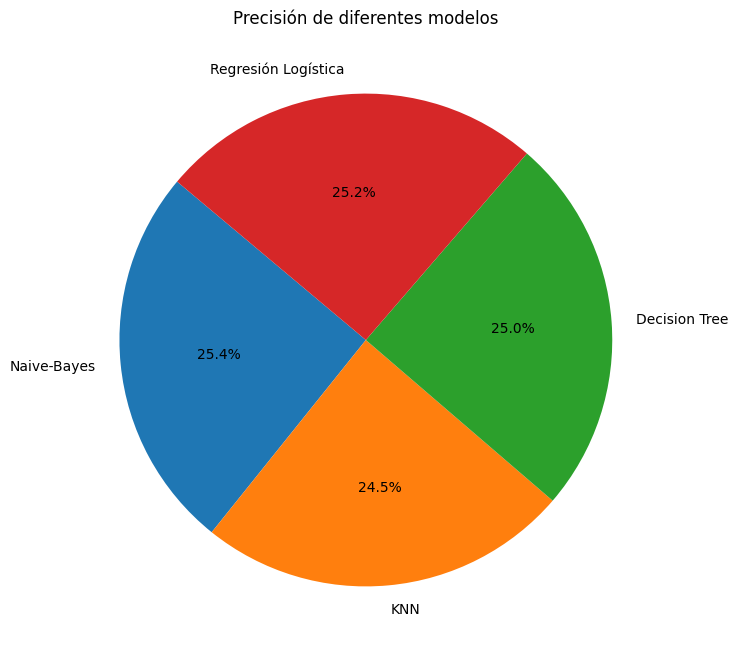

In [ ]:
import matplotlib.pyplot as plt

# Definir los nombres de los modelos y sus respectivas precisión
modelos = ['Naive-Bayes', 'KNN', 'Decision Tree', 'Regresión Logística']
precision = [0.985, 0.95, 0.97, 0.98]

# Crear la gráfica de pastel
plt.figure(figsize=(8, 8))
plt.pie(precision, labels=modelos, autopct='%1.1f%%', startangle=140)

# Añadir título
plt.title('Precisión de diferentes modelos')

# Mostrar la gráfica
plt.show()


Felicidades! Has llegado al final de la práctica 1, eso es todo por hoy.
Espero que hayas aprendido y te resulte útil la práctica para más adelante, el mundo de la IA es inmenso y esta cada vez más presente en un campo como el de la ciberseguridad, quizás vuestros caminos estén destinados a encontrarse... de nuevo.

In [ ]:
# Construir el modelo de red neuronal
# Dividir los datos en conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(spam_df.Message, spam_df.spam, test_size=0.25)

# Inicializar y ajustar CountVectorizer al conjunto de entrenamiento
cv = CountVectorizer()
x_train_count = cv.fit_transform(x_train.values)

# Transformar el conjunto de prueba usando el mismo CountVectorizer ajustado
x_test_count = cv.transform(x_test.values)

# Convertir la matriz dispersa en una matriz densa
x_train_count_dense = x_train_count.toarray()
x_test_count_dense = x_test_count.toarray()

# Construir el modelo de red neuronal
model = Sequential([
    Embedding(input_dim=len(cv.vocabulary_), output_dim=16),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(x_train_count_dense, y_train, epochs=10, batch_size=32, validation_data=(x_test_count_dense, y_test))

# Evaluar el modelo en el conjunto de prueba
loss, accuracy = model.evaluate(x_test_count_dense, y_test)
print(f'Accuracy: {accuracy}')


Epoch 1/10
131/131 [==============================] - 5s 25ms/step - loss: 0.6097 - accuracy: 0.8634 - val_loss: 0.4676 - val_accuracy: 0.8737
Epoch 2/10
131/131 [==============================] - 5s 35ms/step - loss: 0.4125 - accuracy: 0.8634 - val_loss: 0.3800 - val_accuracy: 0.8737
Epoch 3/10
131/131 [==============================] - 3s 21ms/step - loss: 0.3988 - accuracy: 0.8634 - val_loss: 0.3796 - val_accuracy: 0.8737
Epoch 4/10
131/131 [==============================] - 5s 35ms/step - loss: 0.3987 - accuracy: 0.8634 - val_loss: 0.3791 - val_accuracy: 0.8737
Epoch 5/10
131/131 [==============================] - 3s 23ms/step - loss: 0.3986 - accuracy: 0.8634 - val_loss: 0.3789 - val_accuracy: 0.8737
Epoch 6/10
131/131 [==============================] - 3s 25ms/step - loss: 0.3986 - accuracy: 0.8634 - val_loss: 0.3790 - val_accuracy: 0.8737
Epoch 7/10
131/131 [==============================] - 3s 20ms/step - loss: 0.3984 - accuracy: 0.8634 - val_loss: 0.3787 - val_accuracy: 0.8737

In [ ]:
# Mensaje a probar
mensaje = "hello i'm peter"

# Preprocesamiento del mensaje
mensaje_procesado = cv.transform([mensaje])

# Predicción utilizando el modelo
probabilidad_prediccion = model.predict(mensaje_procesado)

# Imprimir la probabilidad de predicción
print("Probabilidad de predicción:", probabilidad_prediccion)

# Clasificación del mensaje (0 o 1) utilizando un umbral de decisión (por ejemplo, 0.5)
clase_prediccion = (probabilidad_prediccion > 0.5).astype(int)
print("Clase predicción:", clase_prediccion)

1/1 [==============================] - 0s 314ms/step
Probabilidad de predicción: [[0.13119797]]
Clase predicción: [[0]]


In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(spam_df.Message, spam_df.spam, test_size=0.25)

# Inicializar y ajustar CountVectorizer al conjunto de entrenamiento
cv = CountVectorizer()
x_train_count = cv.fit_transform(x_train.values)

# Transformar el conjunto de prueba usando el mismo CountVectorizer ajustado
x_test_count = cv.transform(x_test.values)

# Convertir la matriz dispersa en una matriz densa
x_train_count_dense = x_train_count.toarray()
x_test_count_dense = x_test_count.toarray()

# Longitud de la secuencia y dimensiones de las características
longitud_secuencia = x_train_count_dense.shape[1]  # La longitud de la secuencia es la cantidad de palabras
dimensiones_caracteristicas = len(cv.vocabulary_)  # Las dimensiones de las características son el tamaño del vocabulario

# Construir el modelo de CNN
model = Sequential([
    Embedding(input_dim=dimensiones_caracteristicas, output_dim=16, input_length=longitud_secuencia),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo
model.fit(x_train_count_dense, y_train, epochs=10, batch_size=32, validation_data=(x_test_count_dense, y_test))

# Evaluar el modelo en el conjunto de prueba
loss, accuracy = model.evaluate(x_test_count_dense, y_test)
print(f'Accuracy: {accuracy}')

Epoch 1/10
131/131 [==============================] - 34s 237ms/step - loss: 0.2962 - accuracy: 0.8918 - val_loss: 0.0868 - val_accuracy: 0.9706
Epoch 2/10
131/131 [==============================] - 26s 198ms/step - loss: 0.0479 - accuracy: 0.9871 - val_loss: 0.0492 - val_accuracy: 0.9864
Epoch 3/10
131/131 [==============================] - 27s 205ms/step - loss: 0.0182 - accuracy: 0.9952 - val_loss: 0.0504 - val_accuracy: 0.9849
Epoch 4/10
131/131 [==============================] - 28s 211ms/step - loss: 0.0089 - accuracy: 0.9981 - val_loss: 0.0516 - val_accuracy: 0.9871
Epoch 5/10
131/131 [==============================] - 27s 208ms/step - loss: 0.0051 - accuracy: 0.9988 - val_loss: 0.0954 - val_accuracy: 0.9821
Epoch 6/10
131/131 [==============================] - 27s 207ms/step - loss: 0.0040 - accuracy: 0.9990 - val_loss: 0.0574 - val_accuracy: 0.9864
Epoch 7/10
131/131 [==============================] - 28s 217ms/step - loss: 0.0021 - accuracy: 0.9993 - val_loss: 0.0820 - val_ac